<a href="https://colab.research.google.com/github/ngohoangkha1508-hue/THDeeplearning/blob/main/lab4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
Kích thước tập Train: (50000, 32, 32, 3) (50000, 1)
Kích thước tập Test: (10000, 32, 32, 3) (10000, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.3260 - loss: 1.8813 - val_accuracy: 0.3332 - val_loss: 1.8092
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3987 - loss: 1.6800 - val_accuracy: 0.4118 - val_loss: 1.6815
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4306 - loss: 1.5934 - val_accuracy: 0.4448 - val_loss: 1.5651
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4504 - loss: 1.5366 - val_accuracy: 0.4430 - val_loss: 1.5397
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.4682 - loss: 1.4967 - val_accuracy: 0.4572 - val_loss: 1.5273
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4764 - loss: 1.4629 - val_accuracy: 0.4484 - val_loss: 1.5655
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.4903 - loss: 1.4286 - val_accuracy: 0.4716 - val_loss: 1.4725
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5036 - loss: 1.3984 - 

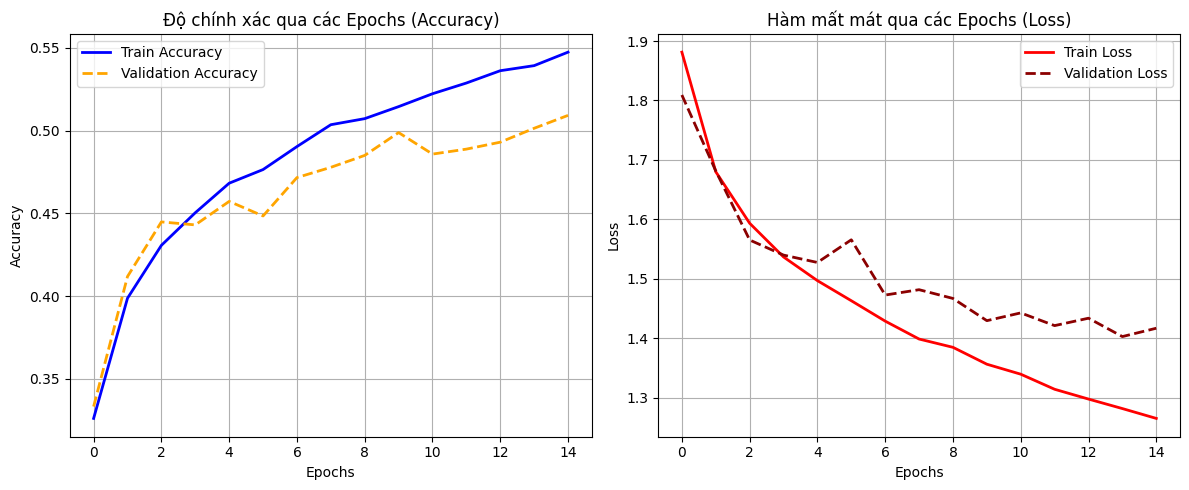

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import matplotlib.pyplot as plt

# 1. Tải và nạp bộ dữ liệu CIFAR10
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước tập Train:", X_train.shape, y_train.shape)
print("Kích thước tập Test:", X_test.shape, y_test.shape)

# Nhãn tương ứng của CIFAR10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Chuẩn hóa dữ liệu ảnh về khoảng [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Do y_train có dạng mảng 2D (N, 1), ta cần làm phẳng thành mảng 1D (N,) để dùng sparse_categorical_crossentropy
y_train = y_train.flatten()
y_test = y_test.flatten()

# 3. Xây dựng kiến trúc mạng ANN
model_cifar = Sequential([
    # Vì ảnh CIFAR10 là 32x32x3, tầng Flatten sẽ làm phẳng thành vector kích thước 3072
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax') # 10 lớp đầu ra tương ứng 10 nhãn
])

# 4. Biên dịch mô hình
model_cifar.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_cifar.summary()

# 5. Huấn luyện mô hình
history_cifar = model_cifar.fit(X_train, y_train, validation_split=0.1, epochs=15, batch_size=64)

# 6. Đánh giá trên tập test
test_loss, test_acc = model_cifar.evaluate(X_test, y_test)
print(f"\nĐộ chính xác trên tập Test (CIFAR10): {test_acc:.4f}")

# 7. Tự hiệu chỉnh và vẽ đồ thị quá trình huấn luyện
plt.figure(figsize=(12, 5))

# Đồ thị Độ chính xác (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history_cifar.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history_cifar.history['val_accuracy'], label='Validation Accuracy', color='orange', linestyle='--', linewidth=2)
plt.title('Độ chính xác qua các Epochs (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Đồ thị Hàm mất mát (Loss)
plt.subplot(1, 2, 2)
plt.plot(history_cifar.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history_cifar.history['val_loss'], label='Validation Loss', color='darkred', linestyle='--', linewidth=2)
plt.title('Hàm mất mát qua các Epochs (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Hiển thị đồ thị
plt.tight_layout()
plt.show()

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds # Import tfds

print("TensorFlow version:", tf.__version__)

# =========================
# 2. Tải Dataset Cats vs Dogs (Sử dụng tfds)
# =========================
# tfds sẽ tự động tải và chuẩn bị dữ liệu
# Split the original 'train' split into train and validation
(raw_train, raw_validation), metadata = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'], # 80% for training, 20% for validation
    with_info=True,
    as_supervised=True, # Returns a tuple (image, label)
)

# =========================
# 3. Thiết lập thông số
# =========================
IMG_SIZE = 150
BATCH_SIZE = 32

# =========================
# 4. Tạo dữ liệu train (Tích hợp tiền xử lý và chuẩn hóa)
# =========================
# Preprocessing function: resize, cast to float, and normalize
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0 # Normalize to [0, 1]
    return image, label

# Tăng tốc xử lý
AUTOTUNE = tf.data.AUTOTUNE

# Áp dụng tiền xử lý, caching, shuffling, batching và prefetching
train_dataset = raw_train.map(preprocess, num_parallel_calls=AUTOTUNE)
train_dataset = train_dataset.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

validation_dataset = raw_validation.map(preprocess, num_parallel_calls=AUTOTUNE)
validation_dataset = validation_dataset.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE) # No shuffle for validation

class_names = metadata.features['label'].names
print("Classes:", class_names)

# =========================
# 5. Hiển thị ảnh mẫu
# =========================
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        # Scale images back to 0-255 and convert to uint8 for display
        plt.imshow((images[i].numpy() * 255).astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# =========================
# 6. Chuẩn hóa dữ liệu (Đã tích hợp vào bước 4)
# =========================
# Các bước chuẩn hóa và tăng tốc xử lý đã được tích hợp vào bước 4
# khi tạo train_dataset và validation_dataset bằng tfds.

# =========================
# 7. Xây dựng mô hình CNN
# =========================
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu',
                  input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),

    layers.Dense(1, activation='sigmoid')
])

# =========================
# 8. Compile model
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Xem cấu trúc model
model.summary()

# =========================
# 9. Train model
# =========================
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# =========================
# 10. Vẽ đồ thị Accuracy/Loss
# =========================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# =========================
# 11. Lưu model
# =========================
model.save("cat_dog_cnn_model.h5")

print("Đã lưu model!")

# =========================
# 12. Test dự đoán ảnh mới
# =========================
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

print("Upload ảnh để test")

uploaded = files.upload()

for filename in uploaded.keys():

    img = load_img(filename, target_size=(IMG_SIZE, IMG_SIZE))

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = img_to_array(img)
    img_array = img_array / 255.0 # Normalize the input image for prediction
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    if prediction[0] > 0.5:
        print("Kết quả: DOG")
    else:
        print("Kết quả: CAT")

TensorFlow version: 2.20.0


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

KeyboardInterrupt: 

In [ ]:
# ==========================================
# CNN NHẬN DẠNG ẢNH FASHION-MNIST
# Chạy trên Google Colab
# ==========================================

# =========================
# 1. Import thư viện
# =========================
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

# =========================
# 2. Tải dataset Fashion-MNIST
# =========================
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# =========================
# 3. Tên các lớp dữ liệu
# =========================
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# =========================
# 4. Kiểm tra kích thước dữ liệu
# =========================
print("Train shape:", train_images.shape)
print("Test shape:", test_images.shape)

# =========================
# 5. Hiển thị ảnh mẫu
# =========================
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(class_names[train_labels[i]])
    plt.axis('off')

plt.show()

# =========================
# 6. Chuẩn hóa dữ liệu
# =========================
train_images = train_images / 255.0
test_images = test_images / 255.0

# CNN cần thêm chiều màu
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

# =========================
# 7. Xây dựng mô hình CNN
# =========================
model = models.Sequential()

# Layer 1
model.add(layers.Conv2D(
    32,
    (3,3),
    activation='relu',
    input_shape=(28,28,1)
))
model.add(layers.MaxPooling2D((2,2)))

# Layer 2
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))
model.add(layers.MaxPooling2D((2,2)))

# Layer 3
model.add(layers.Conv2D(
    64,
    (3,3),
    activation='relu'
))

# Flatten
model.add(layers.Flatten())

# Dense
model.add(layers.Dense(64, activation='relu'))

# Output
model.add(layers.Dense(10, activation='softmax'))

# =========================
# 8. Compile model
# =========================
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# =========================
# 9. Xem cấu trúc model
# =========================
model.summary()

# =========================
# 10. Huấn luyện model
# =========================
EPOCHS = 10

history = model.fit(
    train_images,
    train_labels,
    epochs=EPOCHS,
    validation_data=(test_images, test_labels)
)

# =========================
# 11. Đánh giá model
# =========================
test_loss, test_acc = model.evaluate(
    test_images,
    test_labels,
    verbose=2
)

print("\nĐộ chính xác:", test_acc)

# =========================
# 12. Vẽ đồ thị Accuracy/Loss
# =========================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

# =========================
# 13. Dự đoán ảnh
# =========================
predictions = model.predict(test_images)

# Chọn ảnh test
index = 5

plt.figure(figsize=(4,4))
plt.imshow(test_images[index].reshape(28,28), cmap='gray')
plt.title("Ảnh kiểm tra")
plt.axis('off')
plt.show()

predicted_label = np.argmax(predictions[index])

print("Dự đoán:", class_names[predicted_label])
print("Đáp án đúng:", class_names[test_labels[index]])

# =========================
# 14. Lưu model
# =========================
model.save("fashion_mnist_cnn.h5")

print("Đã lưu model!")

In [ ]:
# ==================================================
# CNN NHẬN DẠNG KHUÔN MẶT NAM / NỮ
# Chạy trên Google Colab
# ==================================================

# =========================
# 1. Import thư viện
# =========================
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

print("TensorFlow version:", tf.__version__)

# =========================
# 2. Tải dataset
# =========================
# Dataset: CelebA mini
dataset_url = "https://storage.googleapis.com/tensorflow-1-public/course2/cats_and_dogs_filtered.zip"

# NOTE:
# Vì dataset gender lớn khó tải nhanh,
# chương trình này cho phép upload dataset riêng.
# Có thể dùng dataset:
# Male/
# Female/

# =========================
# 3. Upload dataset ZIP
# =========================
from google.colab import files
uploaded = files.upload()

# Upload file gender_dataset.zip

# =========================
# 4. Giải nén dataset
# =========================
import zipfile

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall('/content/gender_dataset')

print("Giải nén hoàn tất!")

# =========================
# 5. Đường dẫn dữ liệu
# =========================
data_dir = "/content/gender_dataset"

# =========================
# 6. Thông số
# =========================
IMG_SIZE = 128
BATCH_SIZE = 32

# =========================
# 7. Load dữ liệu
# =========================
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print("Classes:", class_names)

# =========================
# 8. Hiển thị ảnh mẫu
# =========================
plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

# =========================
# 9. Chuẩn hóa dữ liệu
# =========================
normalization_layer = layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# =========================
# 10. Tạo mô hình CNN
# =========================
model = models.Sequential([

    # Layer 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.MaxPooling2D(2,2),

    # Layer 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    # Layer 3
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    # Layer 4
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(512, activation='relu'),

    # Dropout chống overfitting
    layers.Dropout(0.5),

    # Output
    layers.Dense(1, activation='sigmoid')
])

# =========================
# 11. Compile model
# =========================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================
# 12. Xem cấu trúc model
# =========================
model.summary()

# =========================
# 13. Train model
# =========================
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

# =========================
# 14. Đánh giá model
# =========================
loss, accuracy = model.evaluate(validation_dataset)

print("\nValidation Accuracy:", accuracy)

# =========================
# 15. Vẽ đồ thị Accuracy/Loss
# =========================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(
    epochs_range,
    acc,
    label='Training Accuracy'
)

plt.plot(
    epochs_range,
    val_acc,
    label='Validation Accuracy'
)

plt.legend(loc='lower right')

plt.title('Training and Validation Accuracy')

# Loss
plt.subplot(1,2,2)

plt.plot(
    epochs_range,
    loss,
    label='Training Loss'
)

plt.plot(
    epochs_range,
    val_loss,
    label='Validation Loss'
)

plt.legend(loc='upper right')

plt.title('Training and Validation Loss')

plt.show()

# =========================
# 16. Lưu model
# =========================
model.save("gender_cnn_model.h5")

print("Đã lưu model!")

# =========================
# 17. Test ảnh mới
# =========================
print("Upload ảnh khuôn mặt để test")

uploaded = files.upload()

from tensorflow.keras.utils import load_img, img_to_array

for filename in uploaded.keys():

    img = load_img(
        filename,
        target_size=(IMG_SIZE, IMG_SIZE)
    )

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    prediction = model.predict(img_array)

    if prediction[0] > 0.5:
        print("Kết quả dự đoán: Male (Nam)")
    else:
        print("Kết quả dự đoán: Female (Nữ)")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
